# 🎬 Movie Data Analysis — Matplotlib & Seaborn
### A data visualization project exploring movie trends, ratings, genres and more.
**Dataset:** Synthetically generated IMDB-style movie data (300 movies, 1990–2024)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
np.random.seed(42)

genres = ['Action', 'Comedy', 'Drama', 'Thriller', 'Romance', 'Sci-Fi', 'Horror', 'Animation']
directors = ['Christopher Nolan', 'Quentin Tarantino', 'Steven Spielberg',
             'Martin Scorsese', 'James Cameron', 'Ridley Scott', 'Denis Villeneuve']

n = 300

df = pd.DataFrame({
    'title': [f'Movie_{i}' for i in range(n)],
    'genre': np.random.choice(genres, n),
    'director': np.random.choice(directors, n),
    'year': np.random.randint(1990, 2024, n),
    'rating': np.round(np.random.uniform(4.0, 9.5, n), 1),
    'runtime_min': np.random.randint(80, 180, n),
    'votes': np.random.randint(1000, 500000, n),
    'gross_million': np.round(np.random.uniform(1, 500, n), 2)
})

print(df.head())

     title     genre           director  year  rating  runtime_min   votes  \
0  Movie_0    Horror  Christopher Nolan  2005     4.7           90  257689   
1  Movie_1  Thriller  Christopher Nolan  2011     5.8           81  419641   
2  Movie_2   Romance   Steven Spielberg  2018     5.8          146  420901   
3  Movie_3    Horror       Ridley Scott  2003     4.5          166  375999   
4  Movie_4     Drama  Quentin Tarantino  2017     6.6           91  418794   

   gross_million  
0         198.38  
1         487.38  
2         361.22  
3         328.83  
4         378.77  


## 📊 Plot 1 — Genre Popularity
Which genres have the most movies in our dataset?

/tmp/ipykernel_17518/369029309.py:9: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


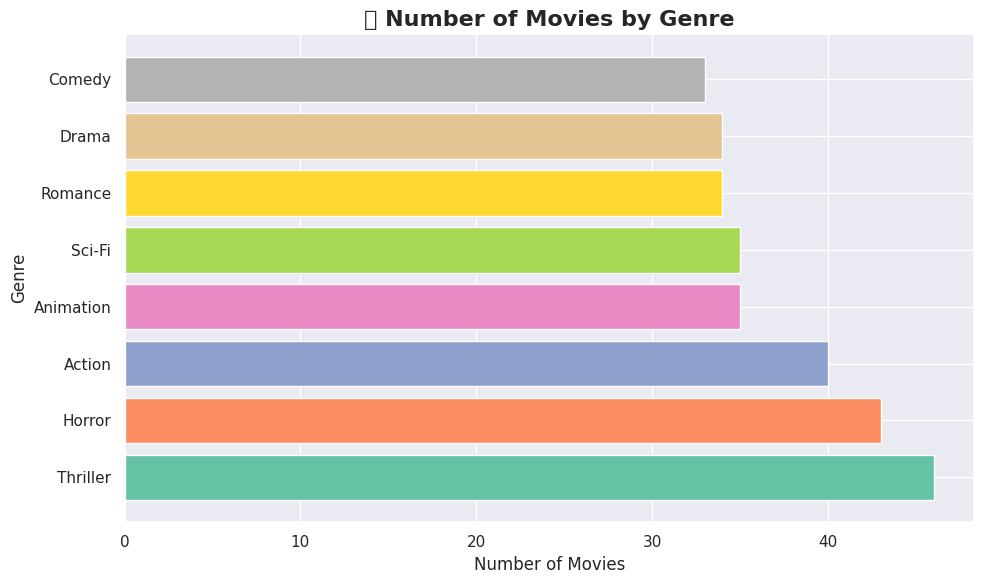

In [3]:
plt.figure(figsize=(10, 6))
genre_counts = df['genre'].value_counts()
colors = sns.color_palette('Set2', len(genre_counts))

plt.barh(genre_counts.index, genre_counts.values, color=colors)
plt.title('🎬 Number of Movies by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

## 📈 Plot 2 — Ratings Distribution
How are movie ratings spread across our dataset?

/tmp/ipykernel_17518/289949769.py:8: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


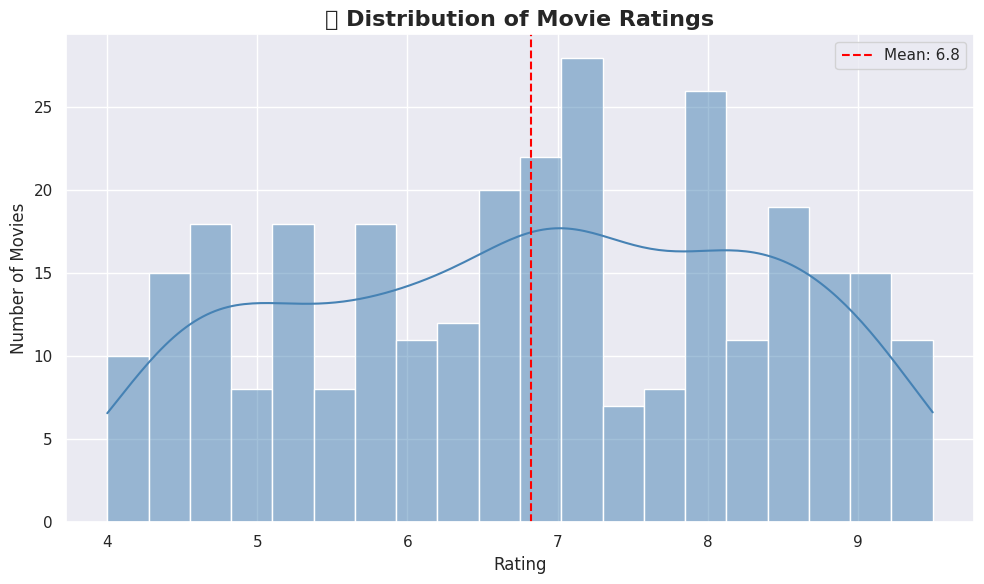

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], bins=20, kde=True, color='steelblue', edgecolor='white')
plt.title('⭐ Distribution of Movie Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.axvline(df['rating'].mean(), color='red', linestyle='--', label=f"Mean: {df['rating'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

## ⭕ Plot 3 — Runtime vs Rating
Do longer movies tend to get better ratings?

/tmp/ipykernel_17518/2801177716.py:8: UserWarning: Glyph 127909 (\N{MOVIE CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127909 (\N{MOVIE CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


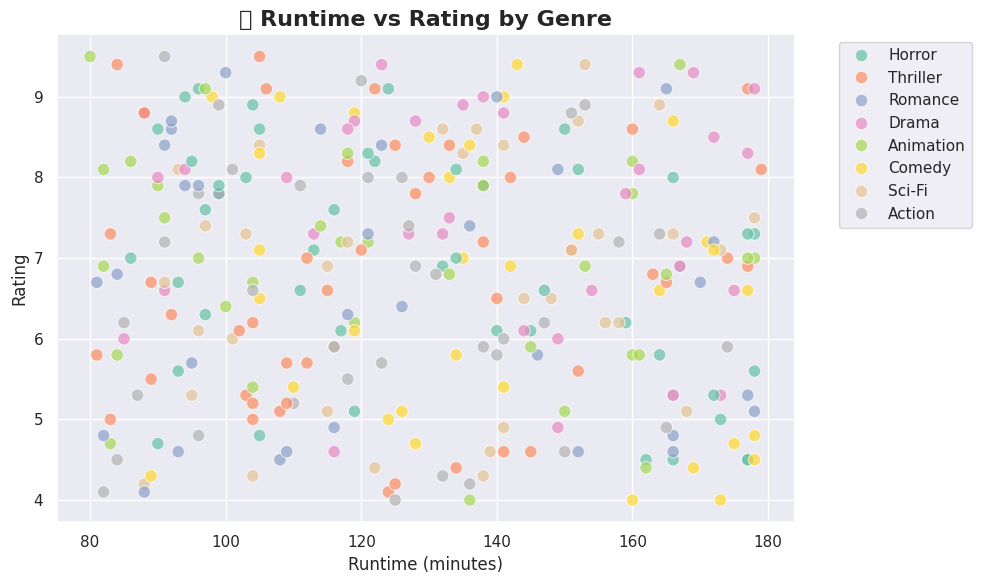

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='runtime_min', y='rating',
                hue='genre', palette='Set2', alpha=0.7, s=80)
plt.title('🎥 Runtime vs Rating by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Runtime (minutes)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 📅 Plot 4 — Movies Released Per Year
How has movie production changed over the decades?

/tmp/ipykernel_17518/2063923357.py:9: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


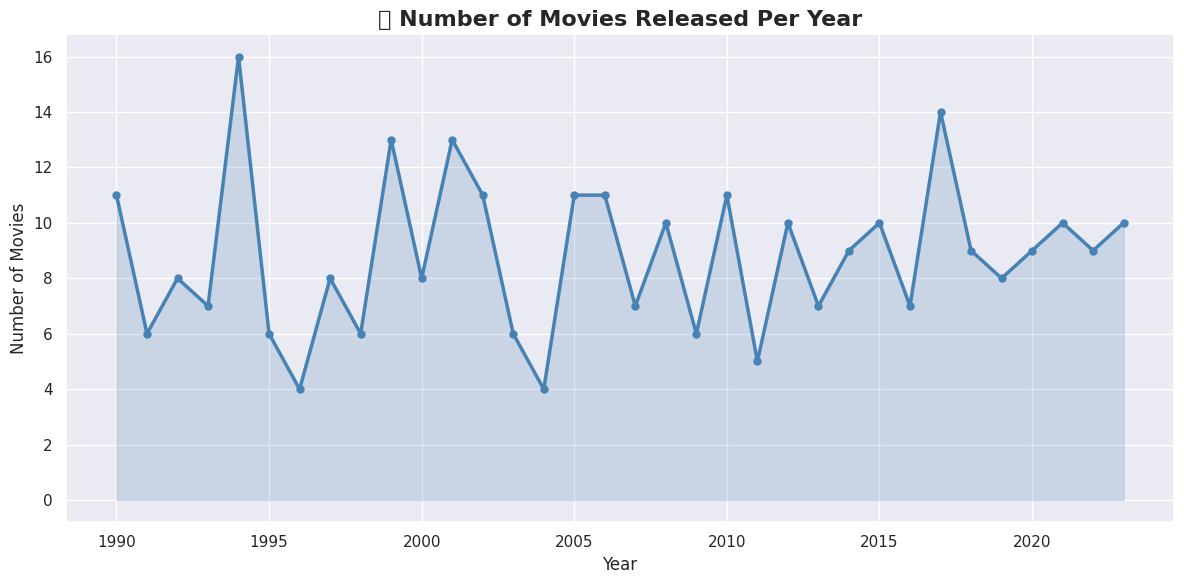

In [6]:
plt.figure(figsize=(12, 6))
movies_per_year = df['year'].value_counts().sort_index()
plt.plot(movies_per_year.index, movies_per_year.values,
         color='steelblue', linewidth=2.5, marker='o', markersize=5)
plt.fill_between(movies_per_year.index, movies_per_year.values, alpha=0.2, color='steelblue')
plt.title('📅 Number of Movies Released Per Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.tight_layout()
plt.show()

## 🔥 Plot 5 — Genre vs Rating Heatmap
Which directors perform best in which genres?

/tmp/ipykernel_17518/3541568697.py:12: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


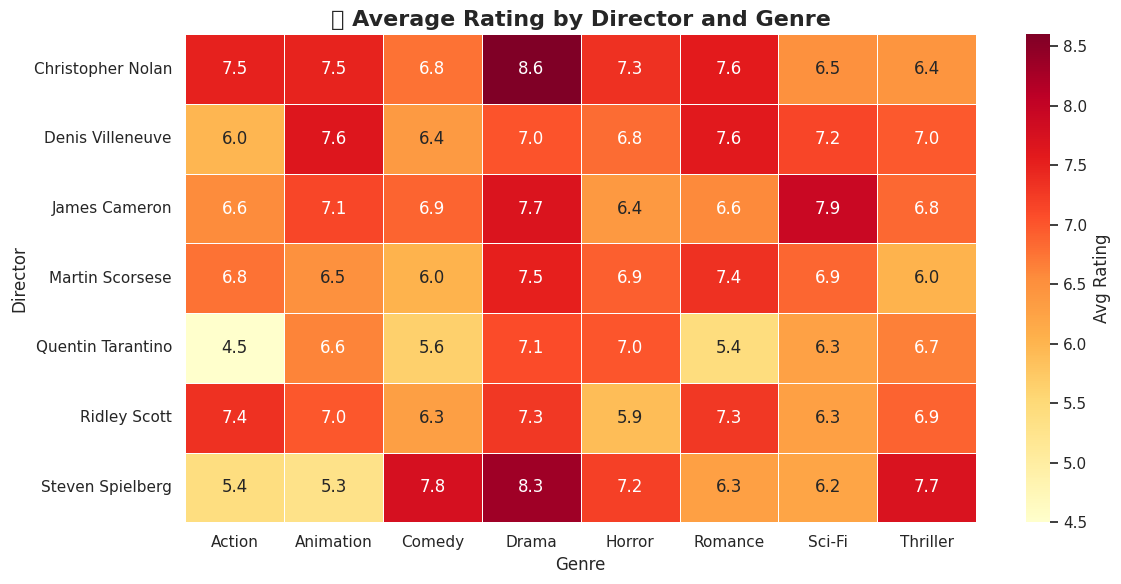

In [7]:
plt.figure(figsize=(12, 6))
heatmap_data = df.pivot_table(values='rating',
                               index='director',
                               columns='genre',
                               aggfunc='mean')
sns.heatmap(heatmap_data, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Rating'})
plt.title('🔥 Average Rating by Director and Genre', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.tight_layout()
plt.show()